# Day 22 - Customer Probability and Distribution Analysis

Day 20에서 생성한 고객 단위 데이터를 이용해
기본 확률, 조건부확률, 확률분포와 z점수를 분석한다.

## 분석 목적

무작위로 고객 한 명을 선택했을 때 특정 고객군에 해당할 확률을 계산한다.

전체 고객 확률과 조건부확률을 비교하고,
고객 주문 수의 경험적 확률분포와 정규분포의 차이를 확인한다.

## 분석 질문

1. 고객 한 명을 선택했을 때 주문 이력이 있을 확률은 얼마인가?
2. 고객 한 명을 선택했을 때 retention_priority일 확률은 얼마인가?
3. VIP이면서 retention_priority일 확률은 얼마인가?
4. VIP 고객 중 retention_priority일 확률은 얼마인가?
5. VIP와 retention_priority는 독립으로 볼 수 있는가?
6. 고객 주문 수의 경험적 확률분포는 어떻게 나타나는가?
7. 주문 수의 기댓값은 실제 평균과 같은가?
8. 주문 수가 9건인 고객은 평균에서 얼마나 떨어져 있는가?
9. 고객 주문 수를 정규분포로 설명할 수 있는가?

## 핵심 개념

- 확률: 사건이 발생할 가능성
- 여사건: 관심 사건이 발생하지 않는 경우
- 교사건: 두 사건이 동시에 발생하는 경우
- 합사건: 두 사건 중 하나 이상이 발생하는 경우
- 조건부확률: 특정 조건이 주어진 집단에서 사건이 발생할 확률
- 독립: 한 사건의 정보가 다른 사건의 확률을 바꾸지 않는 관계
- 확률변수: 무작위 결과를 숫자로 표현한 변수
- 확률분포: 가능한 값과 각 값이 나타날 확률
- z점수: 관측값이 평균에서 표준편차의 몇 배 떨어져 있는지 나타내는 값

In [1]:
# 라이브러리 불러오기
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binom
from scipy.stats import norm

In [2]:
# 프로젝트 경로 설정
project_root = Path.cwd().parent

input_path = (
    project_root
    /"outputs"
    /"customer_order_mini_project.csv"
)

output_dir = project_root / "outputs"

output_dir.mkdir(
    parents = True,
    exist_ok = True
)

print("프로젝트 경로:", project_root)
print("입력 파일 경로:", input_path)
print("출력 경로:", output_dir)

프로젝트 경로: d:\Study\Projects\00_foundation_review
입력 파일 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_mini_project.csv
출력 경로: d:\Study\Projects\00_foundation_review\outputs


In [3]:
# 입력 파일 확인
print(
    "입력 파일 존재 여부:",
    input_path.exists()
)

입력 파일 존재 여부: True


In [4]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(df.head())

   customer_id customer_name   region grade  total_order_count  \
0            1           Kim    Seoul   VIP                  9   
1            5           Han    Seoul   VIP                  8   
2            6          Jung    Busan  GOLD                  7   
3            9          Yoon  Daejeon   VIP                  6   
4           25           Bae  Incheon   VIP                  6   

   paid_order_count  cancelled_order_count  paid_rate first_order_date  \
0                 9                      0      100.0       2026-01-15   
1                 8                      0      100.0       2025-12-20   
2                 6                      1       85.7       2026-01-05   
3                 6                      0      100.0       2026-01-07   
4                 6                      0      100.0       2026-01-12   

  last_order_date data_reference_date  active_period_days  \
0      2026-07-30          2026-07-31               196.0   
1      2026-07-31          2026-07-3

In [5]:
# 데이터 크기 확인
print("행과 열 개수:", df.shape)

행과 열 개수: (30, 18)


In [6]:
# 자료형과 결측치 확인
print(df.dtypes)
print()
print(df.isna().sum())

customer_id                   int64
customer_name                   str
region                          str
grade                           str
total_order_count             int64
paid_order_count              int64
cancelled_order_count         int64
paid_rate                   float64
first_order_date                str
last_order_date                 str
data_reference_date             str
active_period_days          float64
avg_days_between_orders     float64
recency_days                float64
avg_customer_order_count    float64
order_count_rank              int64
activity_status                 str
management_action               str
dtype: object

customer_id                 0
customer_name               0
region                      0
grade                       0
total_order_count           0
paid_order_count            0
cancelled_order_count       0
paid_rate                   0
first_order_date            5
last_order_date             5
data_reference_date         0
active_

In [7]:
# 사건 변수 생성
df["has_order"] = (
    df["total_order_count"] > 0
)

df["is_recent"] = (
    df["activity_status"] == "recent"
)

df["is_retention"] = (
    df["management_action"] == "retention_priority"
)

df["is_vip"] = (
    df["grade"] == "VIP"
)

print(
    df[
        [
            "customer_id",
            "has_order",
            "is_recent",
            "is_retention",
            "is_vip"
        ]
    ].head()
)

   customer_id  has_order  is_recent  is_retention  is_vip
0            1       True       True          True    True
1            5       True       True          True    True
2            6       True       True          True   False
3            9       True       True          True    True
4           25       True       True          True    True


In [8]:
# 불리언 평균 확인
print(
    "has_order 평균:",
    df["has_order"].mean()
)

print(
    "is_recent 평균:",
    df["is_recent"].mean()
)

print(
    "is_vip 평균:",
    df["is_vip"].mean()
)

has_order 평균: 0.8333333333333334
is_recent 평균: 0.5666666666666667
is_vip 평균: 0.26666666666666666


In [9]:
# 기본 확률 계산
customer_count = len(df)

has_order_count = (
    df["has_order"].sum()
)

recent_count = (
    df["is_recent"].sum()
)

retention_count = (
    df["is_retention"].sum()
)

vip_count = (
    df["is_vip"].sum()
)

p_has_order = (
    has_order_count
    / customer_count
)

p_no_order = (
    1
    - p_has_order
)

p_recent = (
    recent_count
    / customer_count
)

p_retention = (
    retention_count
    / customer_count
)

p_vip = (
    vip_count
    / customer_count
)

print(f"p(주문 이력 있음): {p_has_order:.1%}")
print(f"p(주문 이력 없음): {p_no_order:.1%}")
print(f"p(recent): {p_recent:.1%}")
print(f"p(retention): {p_retention:.1%}")
print(f"p(VIP): {p_vip:.1%}")

p(주문 이력 있음): 83.3%
p(주문 이력 없음): 16.7%
p(recent): 56.7%
p(retention): 30.0%
p(VIP): 26.7%


In [10]:
# 교사건과 합사건
retention_and_vip = (
    df["is_retention"]
    & df["is_vip"]
)

retention_or_vip = (
    df["is_retention"]
    | df["is_vip"]
)

retention_and_vip_count = (
    retention_and_vip.sum()
)

retention_or_vip_count = (
    retention_or_vip.sum()
)

p_retention_and_vip = (
    retention_and_vip_count
    / customer_count
)

p_retention_or_vip = (
    retention_or_vip_count
    / customer_count
)

print(
    "retention이면서 VIP인 고객 수:",
    retention_and_vip_count
)

print(
    "retention이거나 VIP인 고객 수:",
    retention_or_vip_count
)

print(
    f"p(retention ∩ VIP): "
    f"{p_retention_and_vip:.1%}"
)

print(
    f"p(retention ∪ VIP): "
    f"{p_retention_or_vip:.1%}"
)

retention이면서 VIP인 고객 수: 7
retention이거나 VIP인 고객 수: 10
p(retention ∩ VIP): 23.3%
p(retention ∪ VIP): 33.3%


In [12]:
# 조건부확률
vip_df = df[
    df["is_vip"]
]

retention_df = df[
    df["is_retention"]
]

p_retention_given_vip = (
    vip_df["is_retention"].mean()
)

p_vip_given_retention = (
    retention_df["is_vip"].mean()
)

print(
    f"P(retention | VIP): "
    f"{p_retention_given_vip:.1%}"
)

print(
    f"P(VIP | retention): "
    f"{p_vip_given_retention:.1%}"
)


P(retention | VIP): 87.5%
P(VIP | retention): 77.8%


In [13]:
# 독립 여부 확인
independent_intersection = (
    p_retention
    * p_vip
)

print(
    "실제 교사건 확률:",
    round(
        p_retention_and_vip,
        4
    )
)

print(
    "독립일 때 예상 교사건 확률:",
    round(
        independent_intersection,
        4
    )
)

print(
    "전체 retention 확률:",
    round(
        p_retention,
        4
    )
)

print(
    "VIP 조건부 retention 확률:",
    round(
        p_retention_given_vip,
        4
    )
)

실제 교사건 확률: 0.2333
독립일 때 예상 교사건 확률: 0.08
전체 retention 확률: 0.3
VIP 조건부 retention 확률: 0.875


In [14]:
# 확률요약표 생성
probability_summary = pd.DataFrame(
    {
        "event": [
            "has_order",
            "no_order",
            "recent",
            "retention_priority",
            "VIP",
            "retention_and_VIP",
            "retention_or_VIP",
            "retention_given_VIP",
            "VIP_given_retention"
        ],
        "numerator": [
            has_order_count,
            customer_count - has_order_count,
            recent_count,
            retention_count,
            vip_count,
            retention_and_vip_count,
            retention_or_vip_count,
            retention_and_vip_count,
            retention_and_vip_count
        ],
        "denominator": [
            customer_count,
            customer_count,
            customer_count,
            customer_count,
            customer_count,
            customer_count,
            customer_count,
            vip_count,
            retention_count
        ]
    }
)

probability_summary["probability"] = (
    probability_summary["numerator"]
    / probability_summary["denominator"]
)

probability_summary["probability"] = (
    probability_summary["probability"]
    .round(4)
)

print(probability_summary)

                 event  numerator  denominator  probability
0            has_order         25           30       0.8333
1             no_order          5           30       0.1667
2               recent         17           30       0.5667
3   retention_priority          9           30       0.3000
4                  VIP          8           30       0.2667
5    retention_and_VIP          7           30       0.2333
6     retention_or_VIP         10           30       0.3333
7  retention_given_VIP          7            8       0.8750
8  VIP_given_retention          7            9       0.7778


In [20]:
# 등급별 조건부확률
grade_probability = df.groupby(
    "grade"
).agg(
    customer_count = ("customer_id", "count"),
    retention_count = ("is_retention", "sum"),
    recent_count = ("is_recent", "sum")
)

grade_probability = (
    grade_probability.reset_index()
)

grade_probability[
    "retention_probability"
] = (
    grade_probability[
        "retention_count"
    ]
    / grade_probability[
        "customer_count"
    ]
)

grade_probability[
    "recent_probability"
] = (
    grade_probability[
        "recent_count"
    ]
    / grade_probability[
        "customer_count"
    ]
)

grade_probability[
    "retention_probability"
] = (
    grade_probability[
        "retention_probability"
    ].round(4)
)

grade_probability[
    "recent_probability"
] = (
    grade_probability[
        "recent_probability"
    ].round(4)
)

print(grade_probability)

   grade  customer_count  retention_count  recent_count  \
0  BASIC              12                1             4   
1   GOLD              10                1             6   
2    VIP               8                7             7   

   retention_probability  recent_probability  
0                 0.0833              0.3333  
1                 0.1000              0.6000  
2                 0.8750              0.8750  


등급별 확률 그래프: d:\Study\Projects\00_foundation_review\outputs\customer_retention_probability_by_grade.png


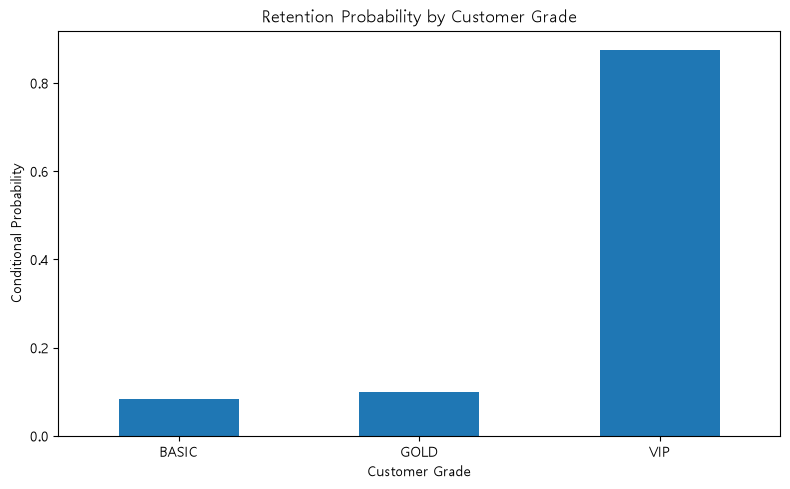

In [21]:
# 등급별 조건부확률 그래프
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

grade_probability.plot.bar(
    x = "grade",
    y = "retention_probability",
    figsize = (8,5),
    legend = False
)

plt.title(
    "Retention Probability by Customer Grade"
)
plt.xlabel("Customer Grade")
plt.ylabel("Conditional Probability")
plt.xticks(rotation=0)
plt.tight_layout()

grade_figure_path = (
    output_dir
    / "customer_retention_probability_by_grade.png"
)

plt.savefig(
    grade_figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show

print(
    "등급별 확률 그래프:",
    grade_figure_path
)

In [31]:
# 주문 수 경험적 확률분포
order_probability = (
    df["total_order_count"]
    .value_counts()
    .sort_index()
)

order_probability_df = (
    order_probability
    .rename_axis(
        "total_order_count"
    )
    .reset_index(
        name = "customer_count"
    )
)

order_probability_df[
    "probability"
] = (
    order_probability_df[
        "customer_count"
    ]
    / customer_count
)

print(order_probability_df)

   total_order_count  customer_count  probability
0                  0               5     0.166667
1                  1               1     0.033333
2                  2               4     0.133333
3                  3               5     0.166667
4                  4               6     0.200000
5                  5               4     0.133333
6                  6               2     0.066667
7                  7               1     0.033333
8                  8               1     0.033333
9                  9               1     0.033333


In [32]:
# 확률분포 검증
distribution_customer_count = (
    order_probability_df[
        "customer_count"
    ].sum()
)

distribution_customer_sum = (
    order_probability_df[
        "probability"
    ].sum()
)

print(
    "고객 수 합계:",
    distribution_customer_count
)

print(
    "확률 합계:",
    distribution_customer_sum
)

고객 수 합계: 30
확률 합계: 1.0


In [34]:
# 기대값 계산
expected_order_count = (
    order_probability_df[
        "total_order_count"
    ]
    * order_probability_df[
        "probability"
    ]
).sum()

actual_order_mean = (
    df["total_order_count"].mean()
)

print(
    "확률분포 기댓값:",
    expected_order_count
)

print(
    "실제 주문 수 평균:",
    actual_order_mean
)


확률분포 기댓값: 3.4666666666666663
실제 주문 수 평균: 3.466666666666667


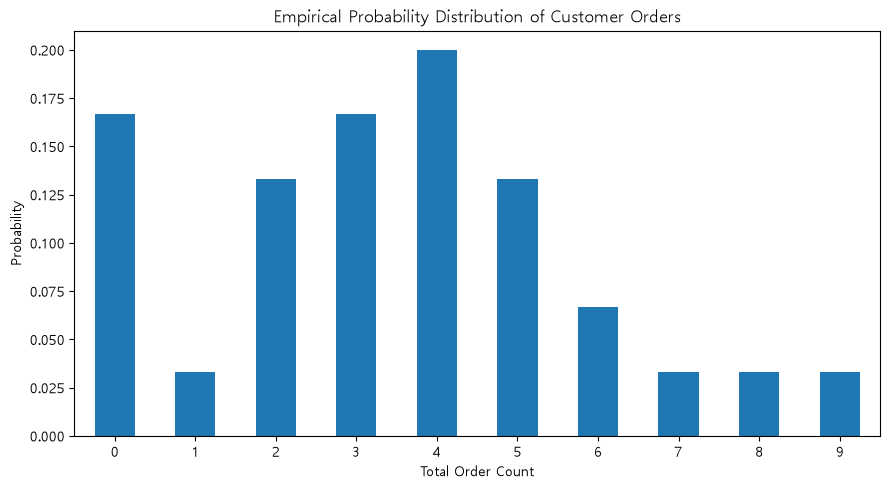

확률분포 그래프: d:\Study\Projects\00_foundation_review\outputs\customer_order_probability_distribution.png


In [35]:
# 주문 수 확률분포 그래프
order_probability_df.plot.bar(
    x="total_order_count",
    y="probability",
    figsize=(9, 5),
    legend=False
)

plt.title(
    "Empirical Probability Distribution of Customer Orders"
)
plt.xlabel("Total Order Count")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.tight_layout()

distribution_figure_path = (
    output_dir
    / "customer_order_probability_distribution.png"
)

plt.savefig(
    distribution_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "확률분포 그래프:",
    distribution_figure_path
)

In [36]:
# 베르누이 변수 확인
retention_bernoulli = (
    df["is_retention"]
    .astype(int)
)

print(
    retention_bernoulli
    .value_counts()
    .sort_index()
)

print(
    "베르누이 변수 평균:",
    retention_bernoulli.mean()
)

print(
    "retention 확률:",
    p_retention
)

is_retention
0    21
1     9
Name: count, dtype: int64
베르누이 변수 평균: 0.3
retention 확률: 0.3


In [37]:
# 이항분포 예제
binomial_probability = binom.pmf(
    2,
    5,
    p_retention
)

print(
    "고객 5명 중 정확히 2명이 "
    "retention_priority일 확률:"
)

print(
    f"{binomial_probability:.2%}"
)

고객 5명 중 정확히 2명이 retention_priority일 확률:
30.87%


In [38]:
# 주문 수 z점수 계산
order_mean = (
    df["total_order_count"].mean()
)

order_std = (
    df["total_order_count"].std()
)

df["order_count_zscore"] = (
    df["total_order_count"]
    - order_mean
) / order_std

print("주문 수 평균:", order_mean)
print("주문 수 표준편차:", order_std)

print(
    df[
        [
            "customer_id",
            "customer_name",
            "total_order_count",
            "order_count_zscore"
        ]
    ].head()
)

주문 수 평균: 3.466666666666667
주문 수 표준편차: 2.3741907272153604
   customer_id customer_name  total_order_count  order_count_zscore
0            1           Kim                  9            2.330619
1            5           Han                  8            1.909423
2            6          Jung                  7            1.488226
3            9          Yoon                  6            1.067030
4           25           Bae                  6            1.067030


In [39]:
# z점수가 높은 고객
zscore_df = df[
    [
        "customer_id",
        "customer_name",
        "region",
        "grade",
        "total_order_count",
        "order_count_zscore",
        "management_action"
    ]
].copy()

zscore_df["order_count_zscore"] = (
    zscore_df["order_count_zscore"]
    .round(3)
)

zscore_df = zscore_df.sort_values(
    "order_count_zscore",
    ascending=False
)

print(zscore_df.head(10))

    customer_id customer_name   region  grade  total_order_count  \
0             1           Kim    Seoul    VIP                  9   
1             5           Han    Seoul    VIP                  8   
2             6          Jung    Busan   GOLD                  7   
3             9          Yoon  Daejeon    VIP                  6   
4            25           Bae  Incheon    VIP                  6   
5            21            Ko  Daejeon    VIP                  5   
6            29            Oh    Seoul    VIP                  5   
9             7          Kang  Incheon  BASIC                  5   
13           15         Hwang  Daejeon    VIP                  5   
7             2           Lee    Busan  BASIC                  4   

    order_count_zscore       management_action  
0                2.331      retention_priority  
1                1.909      retention_priority  
2                1.488      retention_priority  
3                1.067      retention_priority  
4     

In [40]:
# 표준편차 범위별 고객 비율
within_one_std = (
    df["order_count_zscore"]
    .abs()
    <= 1
)

within_two_std = (
    df["order_count_zscore"]
    .abs()
    <= 2
)

within_three_std = (
    df["order_count_zscore"]
    .abs()
    <= 3
)

print(
    "평균 ±1표준편차:",
    f"{within_one_std.mean():.1%}",
    f"({within_one_std.sum()}명)"
)

print(
    "평균 ±2표준편차:",
    f"{within_two_std.mean():.1%}",
    f"({within_two_std.sum()}명)"
)

print(
    "평균 ±3표준편차:",
    f"{within_three_std.mean():.1%}",
    f"({within_three_std.sum()}명)"
)

평균 ±1표준편차: 63.3% (19명)
평균 ±2표준편차: 96.7% (29명)
평균 ±3표준편차: 100.0% (30명)


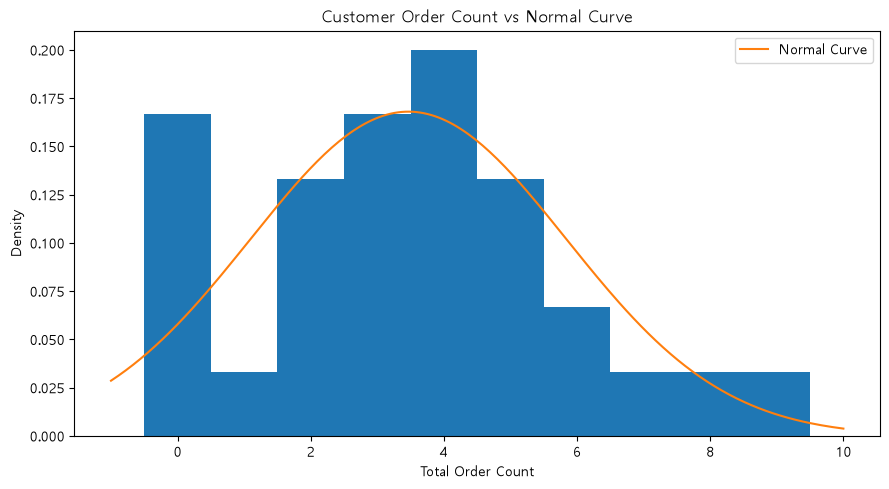

정규곡선 비교 그래프: d:\Study\Projects\00_foundation_review\outputs\customer_order_normal_comparison.png


In [41]:
# 실제 분포와 정규곡선 비교
minimum_order_count = (
    df["total_order_count"].min()
)

maximum_order_count = (
    df["total_order_count"].max()
)

histogram_bins = np.arange(
    minimum_order_count - 0.5,
    maximum_order_count + 1.5,
    1
)

x_values = np.linspace(
    minimum_order_count - 1,
    maximum_order_count + 1,
    200
)

normal_density = norm.pdf(
    x_values,
    loc=order_mean,
    scale=order_std
)

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    df["total_order_count"],
    bins=histogram_bins,
    density=True
)

plt.plot(
    x_values,
    normal_density,
    label="Normal Curve"
)

plt.title(
    "Customer Order Count vs Normal Curve"
)
plt.xlabel("Total Order Count")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

normal_figure_path = (
    output_dir
    / "customer_order_normal_comparison.png"
)

plt.savefig(
    normal_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "정규곡선 비교 그래프:",
    normal_figure_path
)

In [46]:
# 확률 요약 CSV 저장
probability_summary_path = (
    output_dir
    / "customer_probability_summary.csv"
)

probability_summary.to_csv(
    probability_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "확률 요약 CSV:",
    probability_summary_path
)

확률 요약 CSV: d:\Study\Projects\00_foundation_review\outputs\customer_probability_summary.csv


In [42]:
# 주문 수 확률분포 CSV 저장
distribution_path = (
    output_dir
    / "customer_order_probability_distribution.csv"
)

order_probability_df.to_csv(
    distribution_path,
    index = False,
    encoding = "utf-8-sig"
)

print(
    "확률분포 CSV:",
    distribution_path
)

확률분포 CSV: d:\Study\Projects\00_foundation_review\outputs\customer_order_probability_distribution.csv


In [43]:
# 등급별 조건부확률 CSV 저장
grade_probability_path = (
    output_dir
    / "customer_grade_conditional_probability.csv"
)

grade_probability.to_csv(
    grade_probability_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "등급별 조건부확률 CSV:",
    grade_probability_path
)

등급별 조건부확률 CSV: d:\Study\Projects\00_foundation_review\outputs\customer_grade_conditional_probability.csv


In [44]:
# z점수 CSV 저장
zscore_path = (
    output_dir
    / "customer_order_zscore.csv"
)

zscore_df.to_csv(
    zscore_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "z점수 CSV:",
    zscore_path
)

z점수 CSV: d:\Study\Projects\00_foundation_review\outputs\customer_order_zscore.csv


In [47]:
# 저장 결과 확인
print(
    "확률 요약 CSV:",
    probability_summary_path.exists()
)

print(
    "주문 확률분포 CSV:",
    distribution_path.exists()
)

print(
    "등급별 조건부확률 CSV:",
    grade_probability_path.exists()
)

print(
    "z점수 CSV:",
    zscore_path.exists()
)

print(
    "주문 확률분포 그래프:",
    distribution_figure_path.exists()
)

print(
    "등급별 조건부확률 그래프:",
    grade_figure_path.exists()
)

print(
    "정규곡선 비교 그래프:",
    normal_figure_path.exists()
)

확률 요약 CSV: True
주문 확률분포 CSV: True
등급별 조건부확률 CSV: True
z점수 CSV: True
주문 확률분포 그래프: True
등급별 조건부확률 그래프: True
정규곡선 비교 그래프: True


## 핵심 결과

- 전체 고객 중 주문 이력이 있는 고객의 확률은 약 83.3%다.
- 주문 이력이 없는 고객의 확률은 약 16.7%다.
- 전체 고객 중 retention_priority일 확률은 30.0%다.
- 전체 고객 중 VIP일 확률은 약 26.7%다.
- retention_priority이면서 VIP일 확률은 약 23.3%다.
- retention_priority이거나 VIP일 확률은 약 33.3%다.
- VIP 고객 중 retention_priority일 조건부확률은 87.5%다.
- retention_priority 고객 중 VIP일 조건부확률은 약 77.8%다.
- P(retention | VIP)가 P(retention)과 크게 다르므로 현재 데이터에서 두 사건은 독립으로 보기 어렵다.

## 확률분포와 z점수 해석

- 고객 주문 수는 0건부터 9건까지 분포한다.
- 가장 높은 경험적 확률을 가진 주문 수는 4건이며 확률은 20%다.
- 주문 수 확률분포의 기댓값은 약 3.47건으로 실제 산술평균과 같다.
- 주문 수가 9건인 고객의 z점수는 약 2.33으로 평균보다 약 2.33표준편차 높다.
- 전체 고객의 약 63.3%가 평균 ±1표준편차 안에 있다.
- 전체 고객의 약 96.7%가 평균 ±2표준편차 안에 있다.
- 주문 수는 이산형이고 고객 수가 30명으로 적으므로 정규분포를 따른다고 단정할 수 없다.
- 정규곡선은 실제 분포와 비교하기 위한 참고선으로만 사용한다.

## 업무 해석

VIP 고객 중 retention_priority 고객 비율은 87.5%로
전체 고객의 retention_priority 비율인 30%보다 높게 관측됐다.

하지만 이 결과만으로 VIP 등급이 반복 주문을 증가시켰다고 결론 내릴 수 없다.

VIP 등급이 과거 주문 활동을 바탕으로 부여됐을 수 있고,
고객 등급 외에도 가입기간, 지역, 혜택 노출과 같은 요인이
주문 활동에 영향을 줄 수 있기 때문이다.

따라서 현재 결과는 두 사건의 연관성을 보여주는 관측 결과로 해석하고,
인과효과를 판단하려면 등급 부여 시점, 비교군과 시간 순서를 추가로 확인해야 한다.

## 분석 한계

1. 분석 데이터는 학습을 위해 생성한 가상 데이터다.
2. 전체 고객 수가 30명으로 적다.
3. 경험적 확률은 현재 데이터 안에서 관측한 비율이다.
4. 고객별 선택 확률이 실제로 동일하다고 보장할 수 없다.
5. VIP, GOLD와 BASIC 고객의 retention 확률이 다르므로 단순 이항분포 가정이 실제 데이터에 정확히 맞지 않을 수 있다.
6. 조건부확률이 높다는 사실은 인과관계를 증명하지 않는다.
7. 주문 수는 이산형이므로 연속형 정규분포가 정확한 모형이라고 보기 어렵다.
8. z점수 계산은 가능하지만 z점수가 정규분포를 보장하지 않는다.
9. 상품, 주문 금액과 고객 가입기간이 없어 고객 행동의 원인을 분석할 수 없다.